In [1]:
import os
import re
import sys
import json
import itertools
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import gurobipy as gp

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## Load data

In [2]:
REGION = "uk"   # or "kor"
MODULE_DIR = Path.cwd().resolve()
sys.path.insert(0, str(MODULE_DIR))

from inputs import input_files_kor, input_files_uk

fp = input_files_kor if REGION == "kor" else input_files_uk

# Load
edges_raw = json.loads(fp["edges"].read_text(encoding="utf-8"))
routes_nodes = json.loads(fp["route"].read_text(encoding="utf-8"))
dep_time_raw = json.loads(fp["dept"].read_text(encoding="utf-8"))
dem_raw = json.loads(fp["demand"].read_text(encoding="utf-8"))

dep_time = {tr: int(t) for tr, t in dep_time_raw.items()}

# Normalize structures
edges  = {eid: (src, dst, int(tau)) for eid, (src, dst, tau) in edges_raw.items()}
demand = {tr: [(o, d, float(q)) for o, d, q in lst] for tr, lst in dem_raw.items()}

trains = list(routes_nodes)
SINK   = "SINK"
nodes  = {n for _, (s, d, _) in edges.items() for n in (s, d)}
nodes.add(SINK)

## Settings

In [3]:
# Horizon and capacities
T          = 72
max_wait   = 4
CAPACITY_EDGE = 20
CAPACITY_NODE = 20

# Incident window and modelling constants
failed_edges = {"e43", "e43r"}
FAIL_T   = 48
T_clear  = 96
DWELL_MIN = 1
BIG_M     = 10**6

# Helpers
def route_prefix(tr_id: str) -> str:
    m = re.match(r'^([^\d]+)\d+_\d+$', tr_id)
    return m.group(1) if m else tr_id.rsplit('_', 1)[0]

def travel_time_only(path, edges_dict):
    total = 0
    for u, v in zip(path[:-1], path[1:]):
        eid = next(e for e, (s, d, _) in edges_dict.items() if s == u and d == v)
        total += edges_dict[eid][2]
    return total

In [4]:
def build_sched(routes_nodes, edges_dict, dep_time, dwell_min):
    sched = {}
    for tr, path in routes_nodes.items():
        t = dep_time[tr]
        arr = {path[0]: {"arr": t, "dep": t}}
        for i, (u, v) in enumerate(zip(path[:-1], path[1:])):
            eid = next(e for e, (s, d, _) in edges_dict.items() if s == u and d == v)
            t  += edges_dict[eid][2]
            arr[v] = {"arr": t, "dep": t}
            if i < len(path) - 2:
                arr[v]["dep"] += dwell_min
                t += dwell_min
        sched[tr] = arr
    return sched

sched = build_sched(routes_nodes, edges, dep_time, DWELL_MIN)

node_pos = {tr: {n:i for i,n in enumerate(path)} for tr, path in routes_nodes.items()}
edge_tau = {(s, d): tau for _, (s, d, tau) in edges.items()}

def od_distance_on_planned(tr, o, d):
    path = routes_nodes[tr]
    pos  = node_pos[tr]
    if o not in pos or d not in pos or pos[o] >= pos[d]:
        return 0.0
    dist = 0.0
    for i in range(pos[o], pos[d]):
        u, v = path[i], path[i+1]
        dist += edge_tau.get((u, v), 0.0)
    return float(dist)

d_rd, qd_rd = {}, {}
for tr in trains:
    for (o, d, q) in demand[tr]:
        dd = od_distance_on_planned(tr, o, d)
        d_rd[(tr, o, d)]  = dd
        qd_rd[(tr, o, d)] = q * dd

In [5]:
# Group trains by route base
by_route = defaultdict(list)
for tr in trains:
    by_route[route_prefix(tr)].append(tr)

# Representative runtime per route base
route_runtime = {}
for rname, tr_list in by_route.items():
    reps = [tr for tr in tr_list if re.fullmatch(re.escape(rname) + r'\d+_1', tr)]
    if not reps:
        reps = [tr for tr in tr_list if tr.endswith('_1')]
    if not reps:
        reps = [sorted(tr_list)[0]]
    rep = reps[0]
    route_runtime[rname] = travel_time_only(routes_nodes[rep], edges)

# Time limit per train
PADDING_BASE = 6
T_limit = {}
for tr in trains:
    L = len(routes_nodes[tr]) - 1
    dwell_need = max(0, L-1) * DWELL_MIN
    base_run = route_runtime[route_prefix(tr)]
    T_limit[tr] = min(T, dep_time[tr] + base_run + dwell_need + PADDING_BASE)

# Map (u,v) to eid
uv2eid, dup_keys = {}, set()
for eid, (s, d, _) in edges.items():
    key = (s, d)
    if key in uv2eid and uv2eid[key] != eid:
        dup_keys.add(key)
    else:
        uv2eid[key] = eid
if dup_keys:
    print(f"[warn] duplicated (u,v) keys exist: {sorted(list(dup_keys))[:5]} ...")

# Planned eids
def planned_eids_of(tr):
    eids = []
    for u, v in zip(routes_nodes[tr][:-1], routes_nodes[tr][1:]):
        eid = uv2eid.get((u, v))
        if eid is None:
            raise KeyError(f"No edge (u={u} -> v={v}) in edges; check routes_nodes/edges.json")
        eids.append(eid)
    return eids

planned_eids = {tr: planned_eids_of(tr) for tr in trains}
blocked      = {tr: int(any(e in failed_edges for e in planned_eids[tr])) for tr in trains}
T_aff        = [tr for tr in trains if blocked[tr] == 1]
T_ok         = [tr for tr in trains if blocked[tr] == 0]

# Allowable termination nodes after incident position
def get_arrival(tr, node, default=10**9):
    e = sched.get(tr, {}).get(node)
    return e["arr"] if isinstance(e, dict) and ("arr" in e) else default

allow_stop, reach = {}, {}
for tr in trains:
    path  = routes_nodes[tr]
    eids  = planned_eids[tr]
    L     = len(path) - 1
    last  = path[-1]
    t_arrival_last = get_arrival(tr, last, default=10**9)
    reach[tr] = int(t_arrival_last <= T_limit[tr])

    first_fail = next((idx for idx, e in enumerate(eids) if e in failed_edges), None)
    for i in range(1, L + 1):
        n = path[i]
        if i == L:
            allow = 1
        elif reach[tr] == 0:
            allow = 1
        else:
            allow = 1 if (first_fail is not None and i >= (first_fail + 1)) else 0
        allow_stop[(tr, n)] = int(allow)

In [6]:
CROSS = {}
for tr in trains:
    path = routes_nodes[tr]
    t = dep_time[tr]
    for u, v in zip(path[:-1], path[1:]):
        eid = uv2eid[(u, v)]
        tau = edges[eid][2]
        t0, t1 = t, t + tau
        if t0 < FAIL_T <= t1:
            CROSS[tr] = (u, v, eid, t0, t1)
            break
        t = t1
        if v != path[-1]:
            t += DWELL_MIN

In [7]:
def build_arc_list_window(t_start, t_end, failed_edges, T_clear, max_wait,
                          nodes, edges, CROSS):
    arc_list   = []
    blocked_idx = set()

    # travel arcs
    for eid, (src, dst, tau) in edges.items():
        for t in range(t_start, min(t_end, T + 1 - tau)):
            is_block = (eid in failed_edges) and (FAIL_T <= t < T_clear)
            arc_list.append((f"{src}^{t}", f"{dst}^{t+tau}", eid, tau, t, t+tau))
            if is_block:
                blocked_idx.add(len(arc_list) - 1)

    # wait arcs
    for n in nodes - {SINK}:
        for w in range(1, max_wait + 1):
            for t in range(t_start, min(t_end, T + 1 - w)):
                arc_list.append((f"{n}^{t}", f"{n}^{t+w}", f"w_{n}_{w}", w, t, t+w))

    # dummy arcs
    for n in nodes - {SINK}:
        for t in range(t_start, min(t_end, T + 1)):
            arc_list.append((f"{n}^{t}", f"{SINK}^{t}", f"dummy_{n}", 0, t, t))

    # indices and adjacency
    arc_idx = {info: i for i, info in enumerate(arc_list)}
    eid_to_arcidx = defaultdict(list)
    dummy_idx_of  = defaultdict(list)
    wait_idx_of   = defaultdict(list)

    for k, (_, _, eid, *_) in enumerate(arc_list):
        s_eid = str(eid)
        if s_eid.startswith("dummy_"):
            n = s_eid.split("dummy_", 1)[1]
            dummy_idx_of[n].append(k)
        elif s_eid.startswith("w_"):
            parts = s_eid.split("_", 2)
            if len(parts) >= 3:
                n = parts[1]
                wait_idx_of[n].append(k)
        else:
            eid_to_arcidx[eid].append(k)

    out_arcs = defaultdict(list)
    in_arcs  = defaultdict(list)
    node_in_arcs  = defaultdict(list)
    node_out_arcs = defaultdict(list)

    for k, (fr, to, eid, _, t0, t1) in enumerate(arc_list):
        n_fr, tt_fr = fr.split("^"); tt_fr = int(tt_fr)
        n_to, tt_to = to.split("^"); tt_to = int(tt_to)
        out_arcs[(n_fr, tt_fr)].append(k)
        in_arcs [(n_to, tt_to)].append(k)
        s_eid = str(eid)
        if not s_eid.startswith(("w_", "dummy")):
            node_out_arcs[n_fr].append(k)
            node_in_arcs [n_to].append(k)

    # capacity time slots
    cap_map = defaultdict(list)
    for k, (fr, to, eid, _, t0, t1) in enumerate(arc_list):
        if str(eid).startswith(("w_", "dummy")):
            continue
        for tt in range(max(t0, t_start), min(t1, t_end)):
            cap_map[(eid, tt)].append(k)

    # ghost occupancy only after FAIL_T for crossing arcs
    for tr, (u, v, e0, t0, t1) in CROSS.items():
        for tt in range(max(FAIL_T, t_start), min(t1, t_end)):
            cap_map[(e0, tt)].append(-1)

    return {
        "arc_list": arc_list,
        "arc_idx": arc_idx,
        "eid_to_arcidx": eid_to_arcidx,
        "dummy_idx_of": dummy_idx_of,
        "wait_idx_of": wait_idx_of,
        "out_arcs": out_arcs,
        "in_arcs": in_arcs,
        "cap_map": cap_map,
        "node_out_arcs": node_out_arcs,
        "node_in_arcs": node_in_arcs,
        "blocked_idx": blocked_idx,
    }

## Rail scheduling
Dynamic optimization model

In [8]:
def build_model_window(window_ctx, t_start, t_end,
                       planned_eids, routes_nodes,
                       T_aff, T_ok, allow_stop, T_limit):

    arc_list      = window_ctx["arc_list"]
    eid_to_arcidx = window_ctx["eid_to_arcidx"]
    dummy_idx_of  = window_ctx["dummy_idx_of"]
    out_arcs      = window_ctx["out_arcs"]
    in_arcs       = window_ctx["in_arcs"]
    node_out_arcs = window_ctx["node_out_arcs"]
    node_in_arcs  = window_ctx["node_in_arcs"]
    blocked_idx   = window_ctx["blocked_idx"]

    # SOS2 points for delay piecewise
    DELTAS = [0, 6/8, 6/4, 6/2, 6]  # uses PADDING_BASE=6
    GAMMAS = [0.0, 0.25, 0.50, 0.75, 1.0]
    MCOUNT = len(DELTAS)

    m = gp.Model(); m.Params.OutputFlag = 1
    nA, nT = len(arc_list), len(trains)

    enabled_pairs = []
    for ti, tr in enumerate(trains):
        P_eids = set(planned_eids[tr])
        for k, (_, to, eid, tau, t0, t1) in enumerate(arc_list):
            if k in blocked_idx:
                continue  # hard-disable arcs on failed edges during [FAIL_T, T_clear)

            s_eid = str(eid)

            # 1) dummy termination
            if s_eid.startswith("dummy_"):
                n_to = s_eid.split("dummy_", 1)[1]
                if allow_stop.get((tr, n_to), 1) == 0:
                    continue
                enabled_pairs.append((k, ti))
                continue

            # 2) wait arc
            if s_eid.startswith("w_"):
                enabled_pairs.append((k, ti))
                continue

            # 3) real track arc
            if tr in T_ok and (eid not in P_eids):
                continue
            enabled_pairs.append((k, ti))

    x = m.addVars(enabled_pairs, vtype=gp.GRB.BINARY, name="x")

    t_arr = {(tr, n): m.addVar(lb=0, ub=T, vtype=gp.GRB.CONTINUOUS, name=f"tarr[{tr},{n}]")
             for tr in trains for n in nodes - {SINK}}

    delta = {(tr,o,d): m.addVar(lb=0.0, vtype=gp.GRB.CONTINUOUS, name=f"delta[{tr},{o},{d}]")
            for tr in trains for (o,d,_) in demand[tr]}

    gamma = {(tr,o,d): m.addVar(lb=0.0, ub=1.0, vtype=gp.GRB.CONTINUOUS, name=f"gamma[{tr},{o},{d}]")
            for tr in trains for (o,d,_) in demand[tr]}

    lam = {(tr,o,d,k): m.addVar(lb=0.0, vtype=gp.GRB.CONTINUOUS, name=f"lam[{tr},{o},{d},{k}]")
        for tr in trains for (o,d,_) in demand[tr] for k in range(MCOUNT)}

    h = {}; y = {}; s = {}; z = {}; u_eid = {}

    if T_aff:
        h = m.addVars(T_aff, vtype=gp.GRB.BINARY, name="h")
        y = {(tr, n): m.addVar(vtype=gp.GRB.BINARY, name=f"y[{tr},{n}]")
             for tr in T_aff for n in routes_nodes[tr][1:]}
        s = {(tr, n): m.addVar(vtype=gp.GRB.BINARY, name=f"s[{tr},{n}]")
             for tr in T_aff for n in nodes - {SINK}}
        z = {(tr,o,d): m.addVar(vtype=gp.GRB.BINARY, name=f"z[{tr},{o},{d}]")
             for tr in T_aff for (o,d,_) in demand[tr]}

        real_eids = {eid for (_,_,eid,_,_,_) in arc_list if not str(eid).startswith(("w_","dummy"))}
        for tr in T_aff:
            P = set(planned_eids[tr])
            for eid in real_eids:
                if eid in P: 
                    continue
                u_eid[(tr, eid)] = m.addVar(vtype=gp.GRB.BINARY, name=f"u_eid[{tr},{eid}]")
                for k in eid_to_arcidx[eid]:
                    ti = trains.index(tr)
                    if (k, ti) in x:
                        m.addConstr(x[k, ti] <= u_eid[(tr, eid)])

    def sum_x(tr_i, idxs):
        return gp.quicksum(x[k, tr_i] for k in idxs if (k, tr_i) in x)

    # no double use of same arc by same train
    for tr_i, tr in enumerate(trains):
        for eid, idxs in eid_to_arcidx.items():
            m.addConstr(sum_x(tr_i, idxs) <= 1, name=f"L0[{tr},{eid}]")

    # flow conservation (anchor at origin time)
    for tr in trains:
        tr_i = trains.index(tr)
        r_o   = routes_nodes[tr][0]
        t_dep = dep_time[tr]

        out_dep_en = [k for k in out_arcs.get((r_o, t_dep), []) if (k, tr_i) in x]
        in_dep_en  = [k for k in  in_arcs.get((r_o, t_dep), []) if (k, tr_i) in x]

        rhs = h[tr] if tr in T_aff else 1
        if len(out_dep_en) + len(in_dep_en) > 0:
            m.addConstr(gp.quicksum(x[k, tr_i] for k in out_dep_en)
                        - gp.quicksum(x[k, tr_i] for k in in_dep_en) == rhs,
                        name=f"src_origin[{tr},{r_o},{t_dep}]")

        for t in range(t_start, t_end):
            for n in nodes - {SINK}:
                if (n == r_o) and (t == t_dep):
                    continue
                in_idxs  = in_arcs.get((n, t), [])
                out_idxs = out_arcs.get((n, t), [])
                in_en  = [k for k in in_idxs  if (k, tr_i) in x]
                out_en = [k for k in out_idxs if (k, tr_i) in x]
                if not in_en and not out_en:
                    continue
                m.addConstr(gp.quicksum(x[k, tr_i] for k in in_en)
                            == gp.quicksum(x[k, tr_i] for k in out_en),
                            name=f"flow[{tr},{n},{t}]")

    # termination constraints
    for tr in trains:
        ti = trains.index(tr)
        for n in routes_nodes[tr][1:]:
            if allow_stop.get((tr, n), 1) == 0:
                for k in dummy_idx_of.get(n, []):
                    if (k, ti) in x:
                        x[k, ti].UB = 0

    for tr in T_aff:
        ti   = trains.index(tr)
        cand = routes_nodes[tr][1:]
        term = routes_nodes[tr][-1]

        m.addConstr(gp.quicksum(y[tr, n] for n in cand) == h[tr], name=f"aff_y_sum[{tr}]")
        m.addConstr(y[tr, term] >= s[tr, term], name=f"must_term_at_terminal_if_visited[{tr}]")

        for n in cand:
            idx_dum = dummy_idx_of.get(n, [])
            m.addConstr(gp.quicksum(x[k, ti] for k in idx_dum if (k, ti) in x) == y[tr, n],
                        name=f"aff_y_link[{tr},{n}]")
            if allow_stop.get((tr, n), 1) == 0:
                y[tr, n].UB = 0

    for tr in T_ok:
        ti   = trains.index(tr)
        cand = [n for n in routes_nodes[tr][1:] if allow_stop.get((tr, n), 1) == 1]
        lhs_terms = []
        for n in cand:
            lhs_terms.extend([(k, ti) for k in dummy_idx_of.get(n, []) if (k, ti) in x])
        m.addConstr(gp.quicksum(x[key] for key in lhs_terms) == 1, name=f"ok_term_once[{tr}]")

    # dwell constraints
    node_in_eids  = defaultdict(list)
    node_out_eids = defaultdict(list)
    for eid, (u, v, tau) in edges.items():
        node_out_eids[u].append(eid)
        node_in_eids[v].append(eid)

    for tr in trains:
        ti = trains.index(tr)
        origin = routes_nodes[tr][0]
        for i in (nodes - {origin, SINK}):
            in_eids  = node_in_eids.get(i, [])
            out_eids = node_out_eids.get(i, [])
            if not in_eids or not out_eids:
                continue

            for e_in in in_eids:
                idxs_in = [k for k in eid_to_arcidx.get(e_in, []) if (k, ti) in x]
                if not idxs_in:
                    continue
                d_time_in = gp.quicksum(arc_list[k][5] * x[k, ti] for k in idxs_in)

                for e_out in out_eids:
                    idxs_out = [k for k in eid_to_arcidx.get(e_out, []) if (k, ti) in x]
                    if not idxs_out:
                        continue
                    e_time_out  = gp.quicksum(arc_list[k][4] * x[k, ti] for k in idxs_out)
                    alpha_in  = gp.quicksum(x[k, ti] for k in idxs_in)
                    alpha_out = gp.quicksum(x[k, ti] for k in idxs_out)
                    m.addConstr(
                        e_time_out - d_time_in + BIG_M * (2 - alpha_in - alpha_out) >= DWELL_MIN,
                        name=f"dwell[{tr},{i},{e_in}->{e_out}]"
                    )

    # visit and z logic
    for tr in T_aff:
        tr_i = trains.index(tr)
        for n in nodes - {SINK}:
            idx_any = []
            for t in range(t_start, t_end):
                for k in window_ctx["in_arcs"].get((n, t), []):
                    if (k, tr_i) in x and not str(arc_list[k][2]).startswith(("w_","dummy")):
                        idx_any.append(k)
                for k in window_ctx["out_arcs"].get((n, t), []):
                    if (k, tr_i) in x and not str(arc_list[k][2]).startswith(("w_","dummy")):
                        idx_any.append(k)
            if idx_any:
                flow_any = gp.quicksum(x[k, tr_i] for k in set(idx_any))
                s_var = m.addVar(vtype=gp.GRB.BINARY)  # internal link var
                # but we already have s[(tr,n)], so link:
                m.addConstr(flow_any >= s[(tr, n)], name=f"s_lower[{tr},{n}]")
                m.addConstr(flow_any <= BIG_M * s[(tr, n)], name=f"s_upper[{tr},{n}]")
            else:
                s[tr, n].UB = 0

        for n in routes_nodes[tr][1:]:
            m.addConstr(s[tr, n] >= y[tr, n], name=f"visit_if_terminated[{tr},{n}]")

        for (o, d, q) in demand[tr]:
            m.addConstr(z[tr, o, d] <= s[tr, o])
            m.addConstr(z[tr, o, d] <= s[tr, d])
            m.addConstr(z[tr, o, d] >= s[tr, o] + s[tr, d] - 1)
            m.addConstr(z[tr, o, d] <= h[tr])

    # arrival time matching
    for tr_i, tr in enumerate(trains):
        for k, (fr, to, eid, *_ ) in enumerate(arc_list):
            if not (k, tr_i) in x:  # disabled var
                continue
            if str(eid).startswith(("w_", "dummy")):
                continue
            n_to, tt = to.split("^"); tt = int(tt)
            m.addConstr(t_arr[tr, n_to] >= tt - BIG_M * (1 - x[k, tr_i]))
            m.addConstr(t_arr[tr, n_to] <= tt + BIG_M * (1 - x[k, tr_i]))

        # time limit
        Tlim = T_limit[tr]
        if tr in T_aff:
            for n in routes_nodes[tr][1:]:
                m.addConstr(t_arr[tr, n] <= Tlim + BIG_M * (1 - y[tr, n]),
                            name=f"timecap_aff[{tr},{n}]")
        else:
            for n in [nn for nn in routes_nodes[tr][1:] if allow_stop.get((tr, nn), 1) == 1]:
                term_n = gp.quicksum(x[k, tr_i] for k in dummy_idx_of.get(n, []) if (k,tr_i) in x)
                m.addConstr(t_arr[tr, n] <= Tlim + BIG_M * (1 - term_n),
                            name=f"timecap_ok[{tr},{n}]")

    # delay constraints with SOS2
    def sched_arrival(tr, node, default=T):
        entry = sched.get(tr, {}).get(node)
        return entry["arr"] if isinstance(entry, dict) and ("arr" in entry) else default

    for tr in T_aff:
        for (o, d, q) in demand[tr]:
            sched_t = sched_arrival(tr, d, T)
            m.addConstr(delta[tr, o, d] >= t_arr[tr, d] - sched_t - BIG_M * (1 - z[tr, o, d]))
            m.addConstr(delta[tr, o, d] <= BIG_M * z[tr, o, d])
    for tr in T_ok:
        for (o, d, q) in demand[tr]:
            sched_t = sched_arrival(tr, d, T)
            m.addConstr(delta[tr, o, d] >= t_arr[tr, d] - sched_t)

    for tr in trains:
        for (o, d, _) in demand[tr]:
            lam_vars = [lam[(tr,o,d,k)] for k in range(MCOUNT)]
            if tr in T_aff:
                m.addConstr(gp.quicksum(lam_vars) == z[(tr,o,d)], name=f"sos2_sum_aff[{tr},{o},{d}]")
            else:
                m.addConstr(gp.quicksum(lam_vars) == 1.0, name=f"sos2_sum_ok[{tr},{o},{d}]")
            m.addConstr(delta[(tr,o,d)] ==
                        gp.quicksum(DELTAS[k] * lam[(tr,o,d,k)] for k in range(MCOUNT)),
                        name=f"sos2_delta_clip[{tr},{o},{d}]")
            m.addConstr(gamma[(tr,o,d)] ==
                        gp.quicksum(GAMMAS[k] * lam[(tr,o,d,k)] for k in range(MCOUNT)),
                        name=f"sos2_gamma[{tr},{o},{d}]")
            m.addSOS(gp.GRB.SOS_TYPE2, lam_vars, DELTAS)

    # objective
    term_exprs = {}
    def QD(tr, o, d): return qd_rd.get((tr, o, d), 0.0)

    for tr in T_aff:
        total_qd = gp.quicksum(QD(tr, o, d) for (o, d, _) in demand[tr])
        term_exprs[f"aff_cancel[{tr}]"] = total_qd * (1 - h[tr])
        for (o, d, q) in demand[tr]:
            qd_val = QD(tr, o, d)
            term_exprs[f"aff_skip[{tr},{o}->{d}]"]  = qd_val * (1 - z[(tr, o, d)])
            term_exprs[f"aff_delay[{tr},{o}->{d}]"] = qd_val * gamma[(tr, o, d)] * z[(tr, o, d)]
    for key, uvar in u_eid.items():
        tr, eid = key
        term_exprs[f"reroute_penalty[{tr},{eid}]"] = 1.0 * uvar
    for tr in T_ok:
        for (o, d, q) in demand[tr]:
            qd_val = QD(tr, o, d)
            term_exprs[f"ok_delay[{tr},{o}->{d}]"] = qd_val * gamma[(tr, o, d)]

    obj = gp.quicksum(term_exprs.values())
    m.setObjective(obj, sense=gp.GRB.MINIMIZE)
    m._term_exprs = term_exprs

    return m, x, t_arr, delta, h, z, s

In [9]:
t_win_start = 0
t_win_end   = T

print(f"\n==== Window [{t_win_start}, {t_win_end}) ====")

window_ctx = build_arc_list_window(
    t_start=t_win_start, t_end=t_win_end,
    failed_edges=failed_edges, T_clear=T_clear,
    max_wait=max_wait, nodes=nodes, edges=edges,
    CROSS=CROSS
)

base, xvar, t_arr_var, delta_var, hvar, zvar, svar = build_model_window(
    window_ctx, t_win_start, t_win_end,
    planned_eids, routes_nodes,
    T_aff, T_ok, allow_stop, T_limit)

# edge capacity per time
constr_names = {}
for (eid, tt), idxs in window_ctx["cap_map"].items():
    real_idxs = [k for k in idxs if k >= 0]
    enabled_keys = [(k, ti) for k in real_idxs for ti in range(len(trains)) if (k, ti) in xvar]
    if not enabled_keys:
        continue
    expr = gp.quicksum(xvar[k, ti] for (k, ti) in enabled_keys)
    ghost = sum(1 for i in idxs if i < 0)
    rhs = max(0, CAPACITY_EDGE - ghost)
    base.addConstr(expr <= rhs, name=f"edgecap_{eid}_{tt}")
    constr_names[(eid, tt)] = f"edgecap_{eid}_{tt}"

# node capacity via wait arcs occupancy
node_slot_map = defaultdict(list)
for k, (fr, to, eid, _, t0, t1) in enumerate(window_ctx["arc_list"]):
    if not str(eid).startswith("w_"):
        continue
    n_fr, _ = fr.split("^")
    for tt in range(max(t0, t_win_start), min(t1, t_win_end)):
        node_slot_map[(n_fr, tt)].append(k)

def node_cap(n): return CAPACITY_NODE[n] if isinstance(CAPACITY_NODE, dict) else CAPACITY_NODE

for (n, tt), idxs in node_slot_map.items():
    enabled = [(k, ti) for k in idxs for ti in range(len(trains)) if (k, ti) in xvar]
    if not enabled:
        continue
    occ = gp.quicksum(xvar[k, ti] for (k, ti) in enabled)
    base.addConstr(occ <= node_cap(n), name=f"nodecap_{n}_{tt}")

base.optimize()

if base.Status == gp.GRB.OPTIMAL:
    print(f"[OBJ] optimal objective = {base.ObjVal}")
elif base.Status in (gp.GRB.TIME_LIMIT, gp.GRB.INTERRUPTED):
    print(f"[OBJ] incumbent (best found) = {base.ObjVal}")
    print(f"[BND] best bound = {base.ObjBound}")
    print(f"[GAP] MIP gap = {base.MIPGap:.4%}")
elif base.Status == gp.GRB.INFEASIBLE:
    print("Model infeasible.")
else:
    print(f"Status: {base.Status}")

if base.Status == gp.GRB.INFEASIBLE:
    base.computeIIS()
    for c in base.getConstrs():
        if c.IISConstr:
            print(f"[IIS] {c.ConstrName}")
    for v in base.getVars():
        if getattr(v, "IISLB", 0) or getattr(v, "IISUB", 0):
            print(f"[IIS-Var] {v.VarName}  LB:{v.IISLB}  UB:{v.IISUB}")
    base.write(f"iis_win{t_win_start}_{t_win_end}.ilp")
    raise RuntimeError("infeasible (IIS written)")
elif base.Status != gp.GRB.OPTIMAL:
    raise RuntimeError(f"non-optimal status: {base.Status}")

# Extract solution
x_val   = {key: round(var.X) for key, var in xvar.items()}
h_final = {tr: 1.0 for tr in trains}

sol_legs = {tr: [] for tr in trains}
seen_arc_keys = set()

for tr in trains:
    ti = trains.index(tr)
    if tr in T_aff:
        try:
            h_final[tr] = float(hvar[tr].X)
        except KeyError:
            pass
    for k, (fr, to, eid, tau, t0, t1) in enumerate(window_ctx["arc_list"]):
        if x_val.get((k, ti), 0) <= 0.5:
            continue
        if str(eid).startswith(("w_", "dummy")):
            continue
        u, _t0 = fr.split("^"); v, _t1 = to.split("^")
        _t0 = int(_t0); _t1 = int(_t1)
        if _t1 < 0 or _t0 > T:
            continue
        key = (tr, _t0, u, v, _t1, eid)
        if key not in seen_arc_keys:
            seen_arc_keys.add(key)
            sol_legs[tr].append((_t0, u, v, _t1, eid))

print("Complete: sol_legs length =", {tr: len(sol_legs[tr]) for tr in trains})
print("\n==== Optimization done ====")


==== Window [0, 72) ====
Set parameter Username
Set parameter LicenseID to value 2637066
Academic license - for non-commercial use only - expires 2026-03-16
Set parameter OutputFlag to value 1
Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (win64 - Windows 10.0 (19045.2))

CPU model: AMD Ryzen 5 3600XT 6-Core Processor, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 4435788 rows, 6072122 columns and 47203985 nonzeros
Model fingerprint: 0x427145f8
Model has 1090 quadratic objective terms
Model has 4457 SOS constraints
Variable types: 45168 continuous, 6026954 integer (6026954 binary)
Coefficient statistics:
  Matrix range     [3e-01, 1e+06]
  Objective range  [4e-02, 6e+03]
  QObjective range [3e-01, 5e+03]
  Bounds range     [1e+00, 7e+01]
  RHS range        [1e+00, 2e+06]
Presolve removed 32264 rows and 41780 columns (presolve time = 5s)...
Presolve removed 2586318 rows and 4557405 columns (presol

## Rail timetable

In [10]:
def merge_orders(base_order, new_order):
    res = list(base_order)
    for i, node in enumerate(new_order):
        if node in res:
            continue
        prev_node = new_order[i-1] if i > 0 else None
        next_node = new_order[i+1] if i+1 < len(new_order) else None
        if prev_node in res:
            res.insert(res.index(prev_node) + 1, node)
        elif next_node in res:
            res.insert(res.index(next_node), node)
        else:
            res.append(node)
    return res

def build_canonical_station_order(route_ids, routes_nodes):
    order = []
    for rid in route_ids:
        if rid is None:
            continue
        seq = routes_nodes.get(rid, None)
        if not seq:
            continue
        order = merge_orders(order, seq)
    return order

SINK = "SINK"

def sched_arr(tr, node, default=None):
    e = sched.get(tr, {}).get(node)
    if isinstance(e, dict) and ("arr" in e):
        return e["arr"]
    return default

def sched_dep(tr, node, default=None):
    e = sched.get(tr, {}).get(node)
    if isinstance(e, dict) and ("dep" in e):
        return e["dep"]
    return default

def plot_train_paths(train_list, ax, title, h_get, 
                     routes_nodes, sched, station_map, xmax,
                     color=None, label=None,
                     failed_edges=None, edges=None,
                     incident_x0=None, incident_x1=None,
                     show_incident_line=True, show_incident_legend=True):
    if title is not None:
        ax.set_title(title)
    ax.set_xlabel("Timestep")
    ax.set_ylabel("Station")

    order = list(station_map.keys())
    yticks = [station_map[n] for n in order]
    ax.set_yticks(yticks)
    ax.set_yticklabels(order)

    if failed_edges and edges and incident_x0 is not None and incident_x1 is not None:
        drawn_pairs = set()
        for eid in failed_edges:
            if eid not in edges:
                continue
            u, v, _ = edges[eid]
            if (u not in station_map) or (v not in station_map):
                continue
            y0 = station_map[u]; y1 = station_map[v]
            yb, yt = (y0, y1) if y0 <= y1 else (y1, y0)
            key = (min(y0, y1), max(y0, y1))
            if key in drawn_pairs:
                continue
            drawn_pairs.add(key)

            rect = mpatches.Rectangle((incident_x0, yb),   
                                      incident_x1 - incident_x0,  
                                      yt - yb,                  
                                      facecolor=(0.6,0.6,0.6,0.15),  
                                      hatch='////',
                                      edgecolor='lightgray',
                                      linewidth=0,
                                      zorder=0.5)
            ax.add_patch(rect)

        if show_incident_line:
            ax.axvline(incident_x0, color='k', linestyle='--', alpha=0.3, zorder=0.6)

        if show_incident_legend and drawn_pairs:
            patch = mpatches.Patch(facecolor=(0.6,0.6,0.6,0.15), hatch='////',
                                   edgecolor='lightgray', label='Incident block')
            handles, labels = ax.get_legend_handles_labels()
            if 'Incident block' not in labels:
                handles.append(patch)
                labels.append('Incident block')
                ax.legend(handles=handles, fontsize=14, labels=labels)

    if color is None:
        cmap = plt.cm.get_cmap('tab10', max(1, len(train_list)))
        color_iter = (cmap(i % cmap.N) for i in range(len(train_list)))
    else:
        color_iter = (color for _ in range(len(train_list)))

    for tr, tr_color in zip(train_list, color_iter):
        if h_get(tr) < 0.5 and len(sol_legs[tr]) == 0:
            continue

        # planned path (dashed line)
        planned_path = routes_nodes[tr]
        p_nodes = [n for n in planned_path if n in station_map]
        plan_pts = []
        for n in p_nodes:
            t_arr = sched_arr(tr, n, None)
            t_dep = sched_dep(tr, n, None)
            y     = station_map[n]
            if t_arr is not None:
                plan_pts.append((t_arr, y))
            if (t_dep is not None) and (t_arr is not None) and (t_dep < t_arr):
                t_dep = t_arr
            if (t_dep is not None) and (t_dep != t_arr):
                plan_pts.append((t_dep, y))
        plan_pts = sorted(plan_pts, key=lambda xy: xy[0])
        if len(plan_pts) >= 2:
            p_times, p_ys = zip(*plan_pts)
            ax.plot(list(p_times), list(p_ys), linestyle='--', color='gray', alpha=0.7)

        # actual path (solid line)
        actual_legs = sorted(sol_legs[tr], key=lambda x: x[0])
        if not actual_legs:
            continue
        t0, u, v, t1, _ = actual_legs[0]
        if u in station_map and v in station_map:
            ax.plot([t0, t1], [station_map[u], station_map[v]], 
                    color=tr_color, linewidth=2, label=label)
            label = None
        for i in range(1, len(actual_legs)):
            p_t0, p_u, p_v, p_t1, _ = actual_legs[i-1]
            c_t0, c_u, c_v, c_t1, _ = actual_legs[i]
            if c_t0 > p_t1 and p_v == c_u and p_v in station_map:
                ax.plot([p_t1, c_t0], [station_map[p_v], station_map[c_u]],
                        color=tr_color, linewidth=2) 
            if c_u in station_map and c_v in station_map:
                ax.plot([c_t0, c_t1], [station_map[c_u], station_map[c_v]], 
                        color=tr_color, linewidth=2)

    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_xlim(0, xmax)
    ax.set_ylim(1, len(station_map))

In [11]:
def h_get(tr): return float(h_final.get(tr, 1.0))

# Global canonical order (requires user function build_canonical_station_order)
all_route_ids = list(routes_nodes.keys())
try:
    global_order = build_canonical_station_order(all_route_ids, routes_nodes)
except NameError:
    # Fallback if not provided: frequency-based order
    global_order = []
if not global_order:
    cnt = Counter(n for seq in routes_nodes.values() for n in seq if n != SINK)
    global_order = [n for n, _ in cnt.most_common()]
station_map_global = {name: i+1 for i, name in enumerate(global_order)}

# Group by line
by_line = defaultdict(list)
for tr in trains:
    by_line[route_prefix(tr)].append(tr)



# Example 1: all lines in one axis, global y-order
def plot_all_lines_global(xmax=72, figsize=(30, 8)):
    lines_sorted = sorted(by_line.keys())
    cmap = plt.cm.get_cmap("tab20", max(1, len(lines_sorted)))
    line_color = {ln: cmap(i % cmap.N) for i, ln in enumerate(lines_sorted)}
    fig, ax = plt.subplots(figsize=figsize)
    for i, line in enumerate(lines_sorted):
        trs = by_line[line]
        color = line_color[line]
        plot_train_paths(
            trs, ax, title=None,
            h_get=h_get, routes_nodes=routes_nodes, sched=sched,
            station_map=station_map_global, xmax=xmax,
            color=color, label=line,
            failed_edges=failed_edges, edges=edges,
            incident_x0=FAIL_T, incident_x1=T_clear,
            show_incident_line=(i == 0), show_incident_legend=False
        )
    ax.set_xlabel("Timestep"); ax.set_ylabel("Station")
    ax.set_xlim(0, xmax); ax.legend(title="Line", fontsize=14, ncol=2, frameon=True)
    fig.tight_layout(); plt.show()
    return fig, ax



# Example 2: selected lines only, with optional global order
def plot_selected_lines(selected_lines, xmax=100, figsize=(24, 8), use_global_order=False, show_incident_line=True):
    selected_lines = [str(x).strip() for x in selected_lines if str(x).strip()]
    if not selected_lines:
        raise ValueError("selected_lines is empty.")

    local_group = defaultdict(list)
    for tr in trains:
        base = route_prefix(tr)
        if base in selected_lines:
            local_group[base].append(tr)
    if not local_group:
        raise ValueError(f"No trains found for: {selected_lines}")

    if use_global_order:
        station_map = station_map_global
    else:
        sel_trs = [tr for lst in local_group.values() for tr in lst]
        try:
            order = build_canonical_station_order(sel_trs, routes_nodes)
        except NameError:
            order = []
        if not order:
            cnt = Counter(n for tr in sel_trs for n in routes_nodes[tr] if n != SINK)
            order = [n for n, _ in cnt.most_common()]
        station_map = {name: i+1 for i, name in enumerate(order)}

    lines_sorted = sorted(local_group.keys())
    cmap = plt.cm.get_cmap("tab20", max(1, len(lines_sorted)))
    line_color = {ln: cmap(i % cmap.N) for i, ln in enumerate(lines_sorted)}

    fig, ax = plt.subplots(figsize=figsize)
    for i, line in enumerate(lines_sorted):
        trs = local_group[line]
        color = line_color[line]
        plot_train_paths(
            trs, ax, title=None,
            h_get=h_get, routes_nodes=routes_nodes, sched=sched,
            station_map=station_map, xmax=xmax,
            color=color, label=line,
            failed_edges=failed_edges, edges=edges,
            incident_x0=FAIL_T, incident_x1=T_clear,
            show_incident_line=(show_incident_line and i == 0),
            show_incident_legend=False
        )
    ax.set_xlabel("Timestep"); ax.set_ylabel("Station")
    ax.set_xlim(0, xmax); ax.legend(title="Line", fontsize=14, ncol=2, frameon=True)
    fig.tight_layout(); plt.show()
    return fig, ax



# Example 3: dynamic y-order per line
# 1) visited nodes per train from solution legs
visited_by_train = {}
for tr, legs in sol_legs.items():
    nodes_visited = set()
    for _, u, v, _, eid in legs:
        if isinstance(eid, str) and (eid.startswith("w_") or str(eid).startswith("dummy_")):
            continue
        nodes_visited.add(u); nodes_visited.add(v)
    if not nodes_visited and tr in routes_nodes:
        nodes_visited.add(routes_nodes[tr][0])
    visited_by_train[tr] = nodes_visited

# 2) union by line
visited_by_line = {}
for line, trs in by_line.items():
    uni = set()
    for tr in trs:
        uni |= visited_by_train.get(tr, set())
    if SINK in uni:
        uni.remove(SINK)
    visited_by_line[line] = uni

# 3) order builder per line from global order
def build_line_yorder(line):
    S = visited_by_line.get(line, set())
    order = [n for n in global_order if n in S]
    if order:
        return order
    planned = []
    for tr in by_line[line]:
        planned.extend([n for n in routes_nodes[tr] if n != SINK])
    if planned:
        exist  = [n for n in global_order if n in set(planned)]
        remain = [n for n in planned if n not in set(exist)]
        return exist + remain
    return []

# 4) plotting in grid
import math
def plot_lines_dynamic_y(xmax=72):
    lines_sorted = sorted(by_line.keys())
    n_lines = len(lines_sorted)
    n_cols  = 5
    n_rows  = math.ceil(n_lines / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(8*n_cols, 4.5*n_rows), squeeze=False)

    for idx, line in enumerate(lines_sorted):
        r, c = divmod(idx, n_cols)
        ax = axes[r][c]
        trs = by_line[line]
        yorder = build_line_yorder(line) or global_order[:]
        station_map_line = {name: i+1 for i, name in enumerate(yorder)}

        plot_train_paths(
            trs, ax, title=line,
            h_get=h_get, routes_nodes=routes_nodes, sched=sched,
            station_map=station_map_line, xmax=xmax,
            failed_edges=failed_edges, edges=edges,
            incident_x0=FAIL_T, incident_x1=T_clear,
            show_incident_line=True, show_incident_legend=False
        )
        ax.set_yticks(range(1, len(yorder)+1))
        ax.set_yticklabels(yorder)
        ax.set_ylim(0.5, len(yorder)+0.5)
        ax.set_ylabel("Station"); ax.set_xlabel("Timestep")
        ax.set_xlim(0, xmax)

    for k in range(n_lines, n_rows*n_cols):
        r, c = divmod(k, n_cols)
        axes[r][c].axis("off")

    fig.tight_layout()
    plt.show()
    return None

C:\Users\Minji Kang\AppData\Local\Temp\ipykernel_27036\1972576387.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(1, len(lines_sorted)))


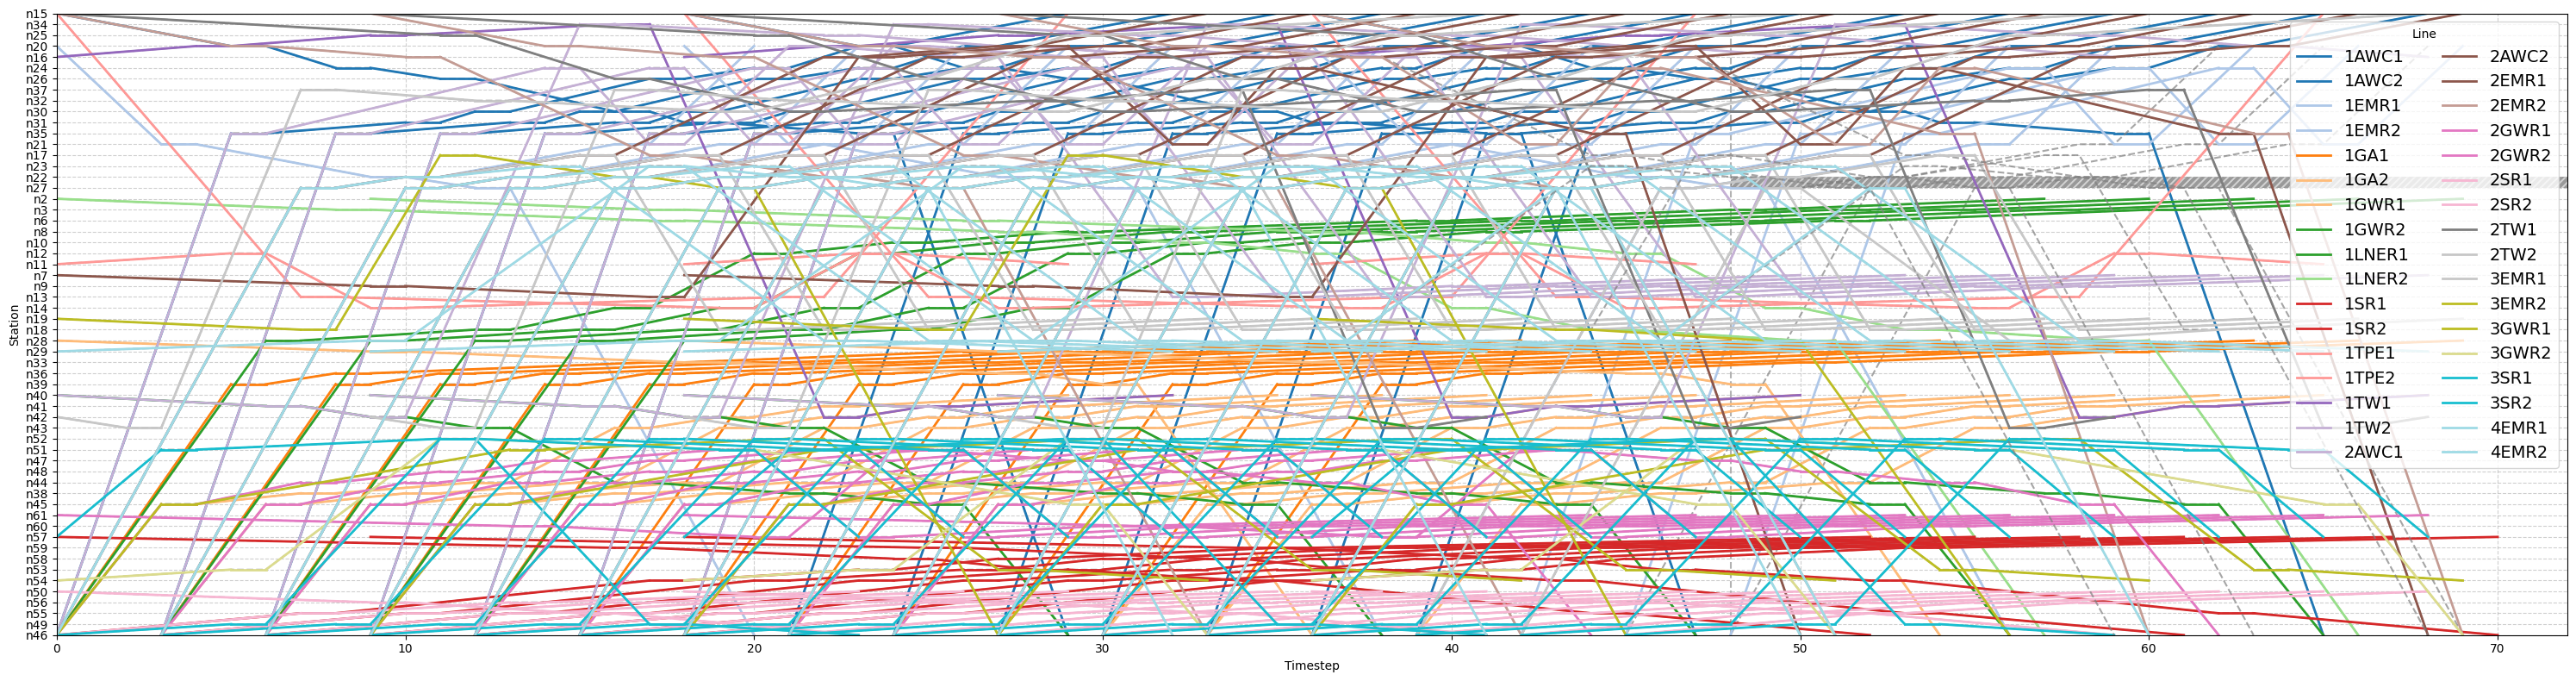

C:\Users\Minji Kang\AppData\Local\Temp\ipykernel_27036\2758566547.py:95: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', max(1, len(train_list)))
C:\Users\Minji Kang\AppData\Local\Temp\ipykernel_27036\2758566547.py:95: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', max(1, len(train_list)))
C:\Users\Minji Kang\AppData\Local\Temp\ipykernel_27036\2758566547.py:95: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instea

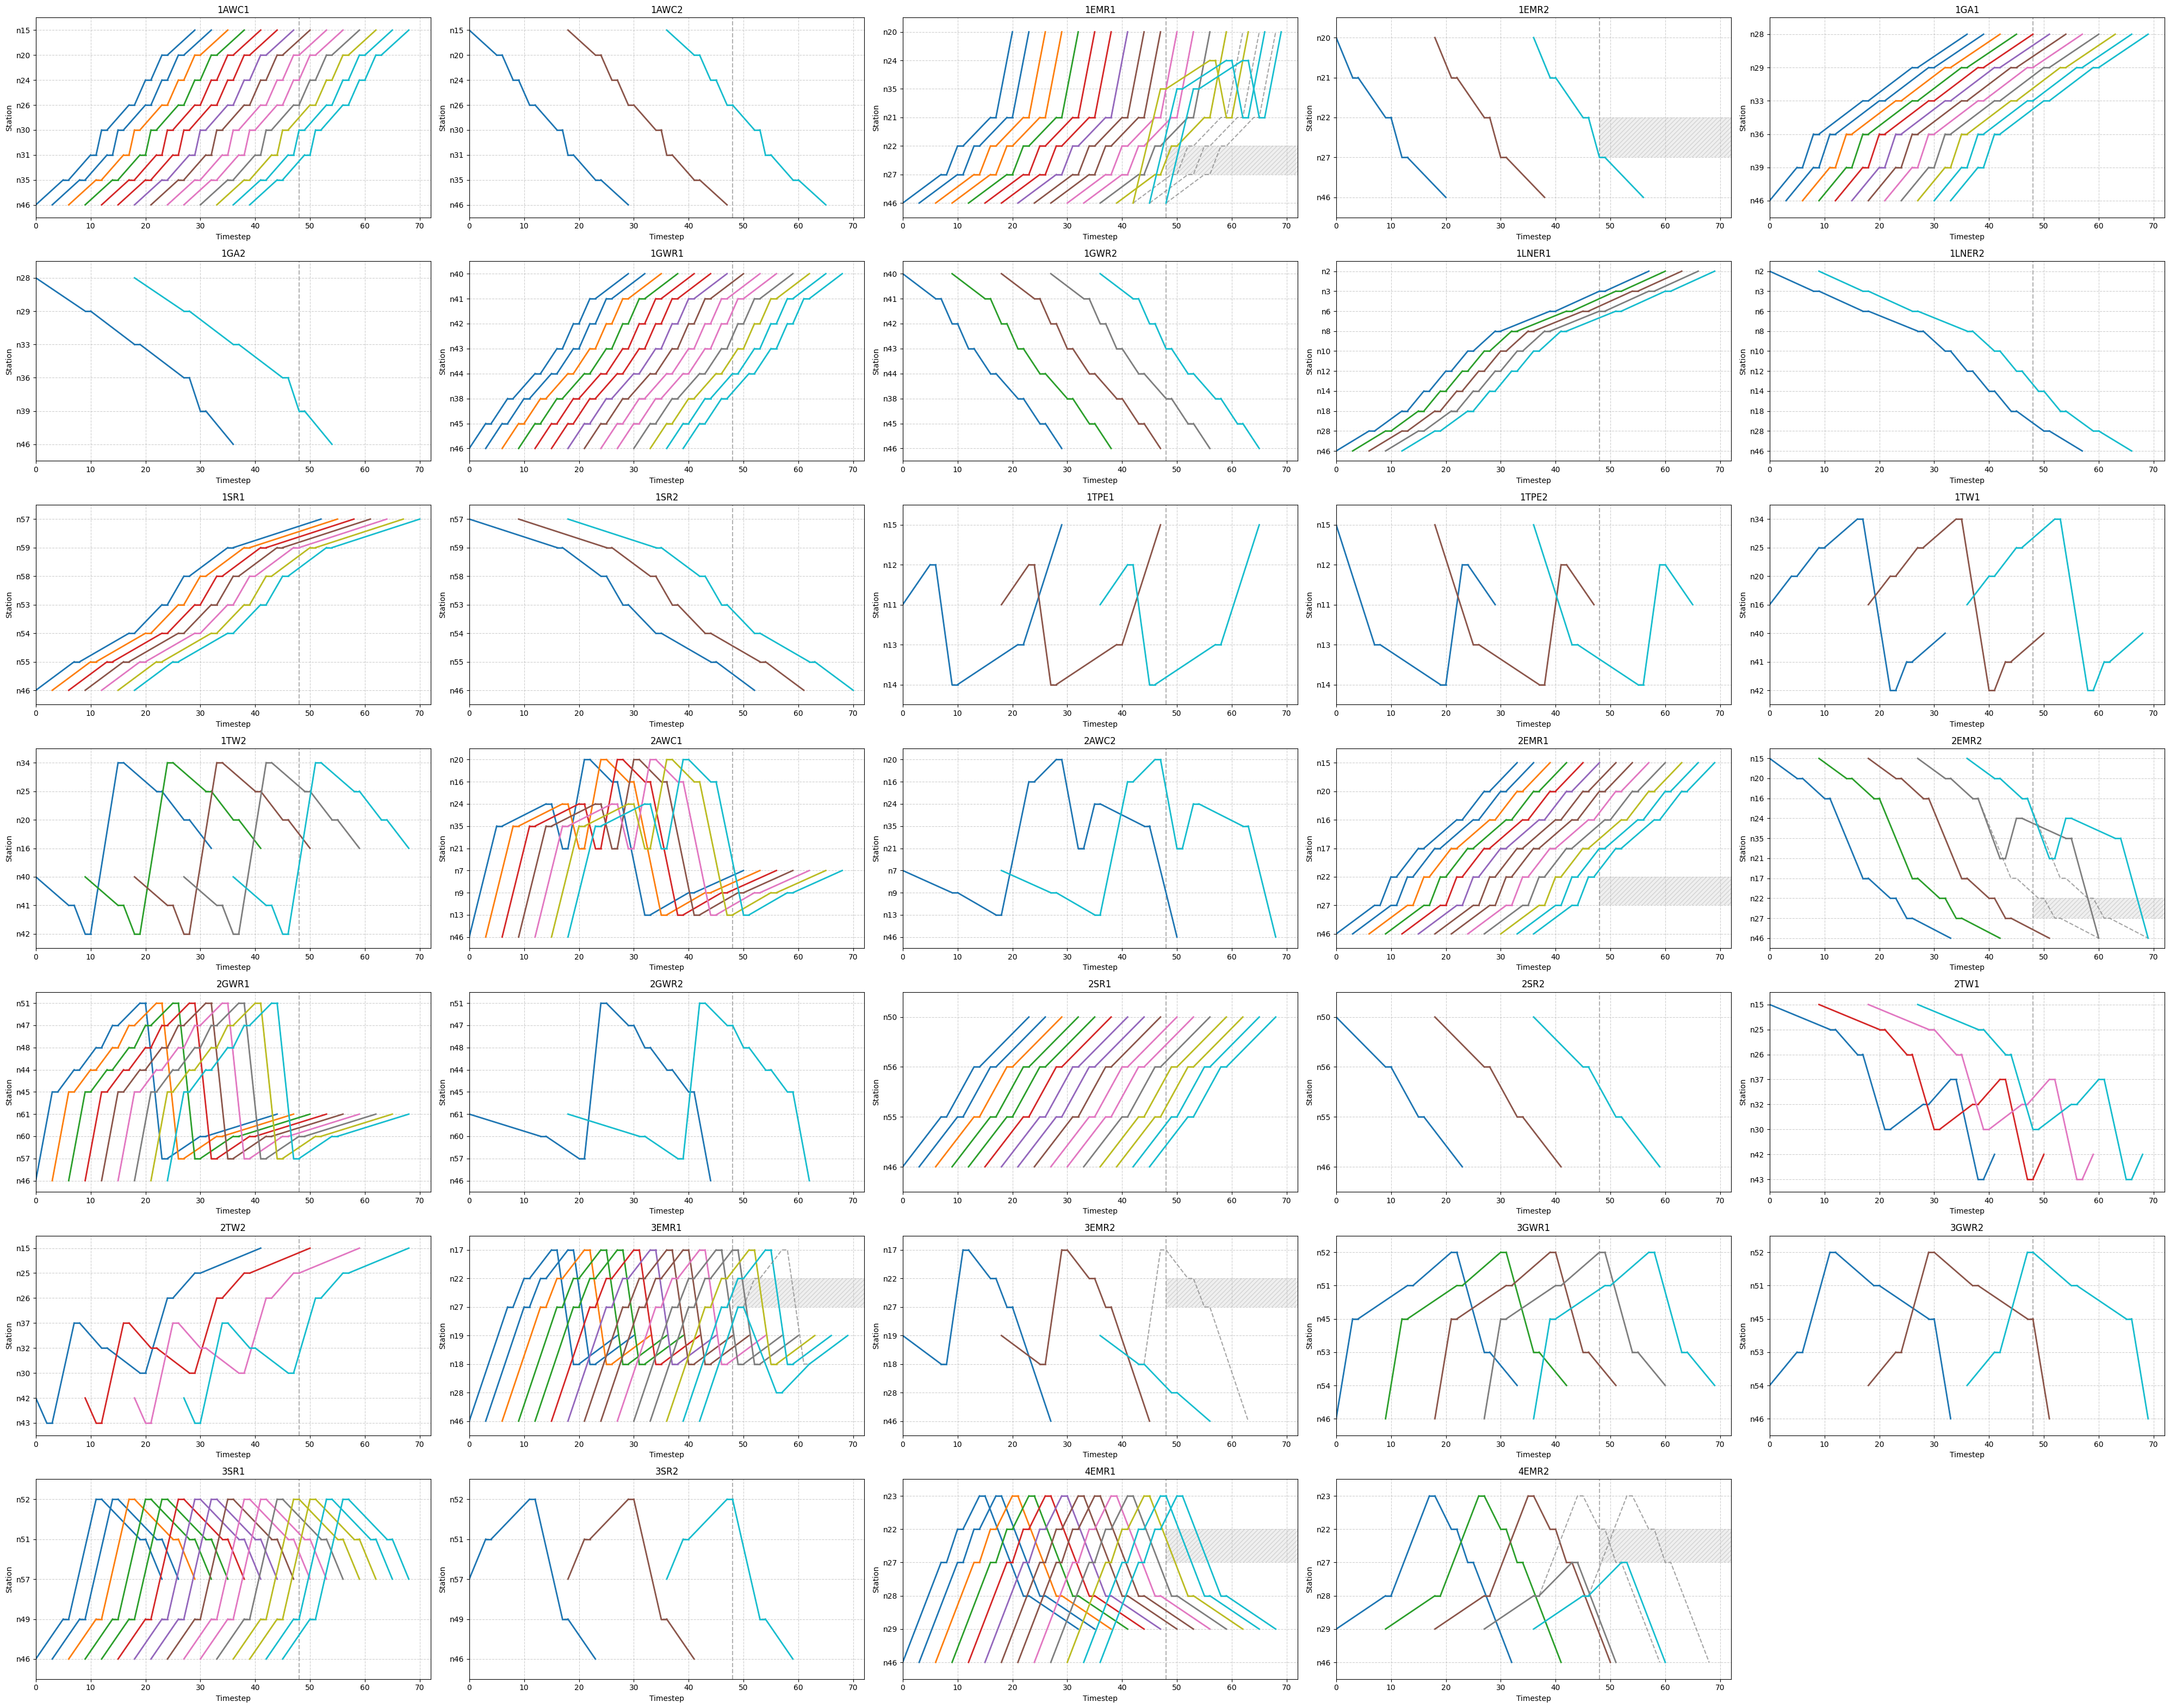

In [12]:
plot_all_lines_global(xmax=72)
plot_lines_dynamic_y(xmax=72)